# Phase 3: Learning Drug-Drug Interactions

This notebook trains several dual-encoder models on the MUDI dataset to learn interaction patterns
between pairs of drugs. The molecular encoder is initialized from Phase 2, and different interaction
heads are compared before selecting the best model for Phase 4.

Main steps:
1. Load the pretrained single-drug encoder
2. Load the processed MUDI train and test graph pairs
3. Create train/validation/test loaders
4. Train multiple dual-encoder interaction models
5. Compare models using macro F1 on the validation set
6. Select the best model and evaluate it on the held-out test set
7. Save the best interaction model and encoder weights

In [ ]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

NameError: name 'torch' is not defined

In [ ]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch_geometric.data import Batch
from torch_geometric.nn import (
    GCNConv, GINConv, GATv2Conv,
    global_mean_pool, global_add_pool,
    BatchNorm
)

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

base_path = r'C:\Users\msi\Downloads\IRP Jupiter nb\Data'
processed_dir = os.path.join(base_path, 'processed_graphs')

mudi_train_path = os.path.join(processed_dir, 'mudi_train.pt')
mudi_test_path = os.path.join(processed_dir, 'mudi_test.pt')
encoder_path = os.path.join(processed_dir, 'pretrained_encoder.pt')
class_weights_path = os.path.join(processed_dir, 'mudi_class_weights.pt')

Using device: cuda


## Reproducibility

Fixing random seeds makes the split and training behavior more stable and reproducible.

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Rebuild the pretrained encoder from Phase 2

The encoder must exactly match the architecture selected in Phase 2 so that pretrained weights can be loaded correctly.
(PyTorch cannot use saved weights by themselves.
It first needs an actual model structure in memory, then the saved weights are loaded into that structure.)

In [ ]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GINConv(mlp2)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GINConv(mlp3)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GATv2Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)

In [ ]:
def build_pretrained_encoder(encoder_meta):
    model_name = encoder_meta["model_name"]
    in_dim = encoder_meta["node_feat_dim"]
    hidden_dim = encoder_meta["hidden_dim"]
    dropout = encoder_meta["dropout"]

    if model_name == "GCN":
        encoder = GCNEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GIN":
        encoder = GINEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GATv2":
        encoder = GATv2Encoder(in_dim, hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown pretrained encoder type: {model_name}")

    encoder.load_state_dict(encoder_meta["encoder_state_dict"])
    return encoder

## Load pretrained encoder metadata

In [ ]:
encoder_meta = torch.load(encoder_path, map_location='cpu')
print("Pretrained encoder type:", encoder_meta["model_name"])
print("Hidden dim:", encoder_meta["hidden_dim"])
print("Node feature dim:", encoder_meta["node_feat_dim"])

Pretrained encoder type: GIN
Hidden dim: 128
Node feature dim: 24


## Load MUDI datasets

The MUDI train and test files already contain graph pairs and labels, so this stage focuses only on interaction learning.

In [ ]:
train_data = torch.load(mudi_train_path, map_location='cpu', weights_only=False)
test_data = torch.load(mudi_test_path, map_location='cpu', weights_only=False)

graphs_a_train, graphs_b_train, labels_train_full = train_data
graphs_a_test, graphs_b_test, labels_test = test_data

labels_train_full = labels_train_full.cpu() if torch.is_tensor(labels_train_full) else torch.tensor(labels_train_full)
labels_test = labels_test.cpu() if torch.is_tensor(labels_test) else torch.tensor(labels_test)

print("MUDI train pairs:", len(labels_train_full))
print("MUDI test pairs:", len(labels_test))
print("Train label distribution:", torch.bincount(labels_train_full))
print("Test label distribution:", torch.bincount(labels_test))

MUDI train pairs: 221115
MUDI test pairs: 89417
Train label distribution: tensor([186268,  27320,   7527])
Test label distribution: tensor([71001, 11914,  6502])


## Dataset class and collate function

Each sample contains two graphs and one class label, so a custom dataset and batching function are needed.

In [ ]:
class MUDIDataset(Dataset):
    def __init__(self, graphs_a, graphs_b, labels):
        self.graphs_a = graphs_a
        self.graphs_b = graphs_b
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.graphs_a[idx], self.graphs_b[idx], int(self.labels[idx])


def collate_ddi(batch):
    graphs_a = [item[0] for item in batch]
    graphs_b = [item[1] for item in batch]
    labels = [item[2] for item in batch]

    batch_a = Batch.from_data_list(graphs_a)
    batch_b = Batch.from_data_list(graphs_b)
    labels = torch.tensor(labels, dtype=torch.long)

    return batch_a, batch_b, labels

## Stratified train/validation split

Because MUDI is imbalanced, the validation split should preserve class proportions.

In [ ]:
labels_np = labels_train_full.numpy()

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(splitter.split(np.zeros(len(labels_np)), labels_np))

train_dataset = MUDIDataset(
    [graphs_a_train[i] for i in train_idx],
    [graphs_b_train[i] for i in train_idx],
    [labels_np[i] for i in train_idx]
)

val_dataset = MUDIDataset(
    [graphs_a_train[i] for i in val_idx],
    [graphs_b_train[i] for i in val_idx],
    [labels_np[i] for i in val_idx]
)

test_dataset = MUDIDataset(graphs_a_test, graphs_b_test, labels_test.tolist())

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 199003
Validation size: 22112
Test size: 89417


## Weighted sampler and class weights

MUDI has serious class imbalance. Weighted sampling increases minority-class exposure, and class-weighted loss reduces majority-class bias.

In [ ]:
class_weights = torch.load(class_weights_path, map_location='cpu')
if not torch.is_tensor(class_weights):
    class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = class_weights.to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.3957, 2.6978, 9.7921], device='cuda:0')


In [ ]:
train_labels_for_sampler = np.array([train_dataset[i][2] for i in range(len(train_dataset))])
class_counts = np.bincount(train_labels_for_sampler)
sample_weights = 1.0 / class_counts[train_labels_for_sampler]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

## DataLoaders

These loaders feed graph pairs into the model efficiently during training and evaluation.

In [ ]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    collate_fn=collate_ddi
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_ddi
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_ddi
)

## Candidate dual-encoder interaction models

Instead of trying only one interaction design, multiple interaction heads are compared.

Why these models were selected

- **ConcatMLP** is the simplest baseline and checks whether direct concatenation is enough.

- **ConcatProdMLP** adds element-wise product, which is useful for capturing pairwise interaction signals.

- **BilinearConcatProd** adds a bilinear term, which explicitly models cross-drug feature interactions and is often stronger for pair prediction.

In [ ]:
class DualEncoderConcatMLP(nn.Module):
    def __init__(self, encoder, num_classes=3, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        combined = torch.cat([emb_a, emb_b], dim=1)
        logits = self.classifier(combined)
        return logits, combined


class DualEncoderConcatProdMLP(nn.Module):
    def __init__(self, encoder, num_classes=3, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        combined = torch.cat([emb_a, emb_b, prod], dim=1)
        logits = self.classifier(combined)
        return logits, combined


class DualEncoderBilinearConcatProd(nn.Module):
    def __init__(self, encoder, num_classes=3, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.bilinear = nn.Bilinear(emb_dim, emb_dim, emb_dim)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        bilinear_term = self.bilinear(emb_a, emb_b)
        combined = torch.cat([emb_a, emb_b, prod, bilinear_term], dim=1)
        logits = self.classifier(combined)
        return logits, combined

## Build model function

This lets all candidate models be trained in a consistent way.

In [ ]:
def build_interaction_model(model_name, encoder_meta, num_classes=3, dropout=0.2):
    encoder = build_pretrained_encoder(encoder_meta)

    if model_name == "ConcatMLP":
        model = DualEncoderConcatMLP(encoder, num_classes=num_classes, dropout=dropout)
    elif model_name == "ConcatProdMLP":
        model = DualEncoderConcatProdMLP(encoder, num_classes=num_classes, dropout=dropout)
    elif model_name == "BilinearConcatProd":
        model = DualEncoderBilinearConcatProd(encoder, num_classes=num_classes, dropout=dropout)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return model

## Training and evaluation helpers

These functions keep training consistent and make comparison between candidate models fair.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=2.0):
    model.train()
    total_loss = 0.0

    for batch_a, batch_b, labels in loader:
        batch_a = batch_a.to(device)
        batch_b = batch_b.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(batch_a, batch_b)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

    return total_loss / len(loader.dataset)


def evaluate_classifier(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    all_embeddings = []

    with torch.no_grad():
        for batch_a, batch_b, labels in loader:
            batch_a = batch_a.to(device)
            batch_b = batch_b.to(device)
            labels = labels.to(device)

            logits, embeddings = model(batch_a, batch_b)
            loss = criterion(logits, labels)

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_embeddings.extend(embeddings.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_embeddings = np.array(all_embeddings)

    acc = accuracy_score(all_labels, all_preds)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "preds": all_preds,
        "labels": all_labels,
        "probs": all_probs,
        "embeddings": all_embeddings
    }

## Training routine for candidate models

All candidate models are trained under the same conditions and selected using validation macro F1, which is more suitable than accuracy for imbalanced multi-class data.

In [ ]:
def train_candidate_model(model_name, encoder_meta, train_loader, val_loader, class_weights, device,
                          lr=1e-3, weight_decay=1e-5, max_epochs=200, patience=10,
                          freeze_encoder_epochs=3):

    model = build_interaction_model(model_name, encoder_meta, num_classes=3, dropout=0.2).to(device)

    for p in model.encoder.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    history = []
    best_val_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    wait = 0

    for epoch in range(1, max_epochs + 1):
        if epoch == freeze_encoder_epochs + 1:
            for p in model.encoder.parameters():
                p.requires_grad = True

            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=0.5, patience=3
            )

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate_classifier(model, val_loader, criterion, device)

        scheduler.step(val_metrics["macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "lr": optimizer.param_groups[0]["lr"]
        }
        history.append(row)

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = {
                "model_name": model_name,
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "encoder_meta": encoder_meta,
                "best_epoch": best_epoch,
                "best_val_macro_f1": best_val_macro_f1
            }
            wait = 0
            print(f"[{model_name}] Epoch {epoch:03d}: new best Val Macro F1 = {best_val_macro_f1:.4f}")
        else:
            wait += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[{model_name}] Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
                f"Val Acc: {val_metrics['accuracy']:.4f} | "
                f"Val Macro F1: {val_metrics['macro_f1']:.4f} | "
                f"Val Weighted F1: {val_metrics['weighted_f1']:.4f}"
            )

        if wait >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch:03d}. Best epoch was {best_epoch:03d}")
            break

    history_df = pd.DataFrame(history)
    return best_state, history_df

## Train and compare candidate interaction models

This is the main model-selection stage for Phase 3. The best model is the one that learns the most balanced interaction patterns across all classes.

In [ ]:
candidate_models = ["ConcatMLP", "ConcatProdMLP", "BilinearConcatProd"]

all_results = []
all_histories = {}
best_overall = None
best_overall_macro_f1 = -1.0
best_model_name = None

In [ ]:
for model_name in candidate_models:
    print(f"\n========== Training {model_name} ==========")

    best_state, history_df = train_candidate_model(
        model_name=model_name,
        encoder_meta=encoder_meta,
        train_loader=train_loader,
        val_loader=val_loader,
        class_weights=class_weights,
        device=device,
        lr=1e-3,
        weight_decay=1e-5,
        max_epochs=200,
        patience=10,
        freeze_encoder_epochs=3
    )

    all_histories[model_name] = history_df

    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()].to_dict()
    best_row["model_name"] = model_name
    all_results.append(best_row)

    if best_row["val_macro_f1"] > best_overall_macro_f1:
        best_overall_macro_f1 = best_row["val_macro_f1"]
        best_overall = best_state
        best_model_name = model_name


========== Training ConcatMLP ==========
[ConcatMLP] Epoch 001: new best Val Macro F1 = 0.1438
[ConcatMLP] Epoch 001 | Train Loss: 0.4440 | Val Loss: 1.2864 | Val Acc: 0.1306 | Val Macro F1: 0.1438 | Val Weighted F1: 0.0496
[ConcatMLP] Epoch 002: new best Val Macro F1 = 0.1525
[ConcatMLP] Epoch 003: new best Val Macro F1 = 0.1629
[ConcatMLP] Epoch 004: new best Val Macro F1 = 0.2151
[ConcatMLP] Epoch 005: new best Val Macro F1 = 0.2422
[ConcatMLP] Epoch 005 | Train Loss: 0.2107 | Val Loss: 0.9030 | Val Acc: 0.2456 | Val Macro F1: 0.2422 | Val Weighted F1: 0.2188
[ConcatMLP] Epoch 006: new best Val Macro F1 = 0.2676
[ConcatMLP] Epoch 007: new best Val Macro F1 = 0.2977
[ConcatMLP] Epoch 008: new best Val Macro F1 = 0.3404
[ConcatMLP] Epoch 009: new best Val Macro F1 = 0.4018
[ConcatMLP] Epoch 010 | Train Loss: 0.1222 | Val Loss: 0.6733 | Val Acc: 0.4537 | Val Macro F1: 0.4016 | Val Weighted F1: 0.4998
[ConcatMLP] Epoch 011: new best Val Macro F1 = 0.4059
[ConcatMLP] Epoch 012: new best

In [ ]:
results_df = pd.DataFrame(all_results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
results_df

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,lr,model_name
0,96.0,0.019032,0.226303,0.910953,0.834493,0.918186,0.000016,ConcatMLP
1,101.0,0.018105,0.252385,0.900868,0.813400,0.909445,0.000002,ConcatProdMLP
2,128.0,0.027033,0.331673,0.868081,0.775590,0.881801,0.000002,BilinearConcatProd


## Brief interpretation of model selection

In [ ]:
print("Best model selected for Phase 4:", best_model_name)
print(results_df[["model_name", "val_accuracy", "val_macro_f1", "val_weighted_f1"]])

Best model selected for Phase 4: ConcatMLP
           model_name  val_accuracy  val_macro_f1  val_weighted_f1
0           ConcatMLP      0.910953      0.834493         0.918186
1       ConcatProdMLP      0.900868      0.813400         0.909445
2  BilinearConcatProd      0.868081      0.775590         0.881801


## Model Comparison Results

Three dual-encoder interaction models were evaluated for learning drug–drug interaction patterns: **ConcatMLP**, **ConcatProdMLP**, and **BilinearConcatProd**. Performance was compared using validation metrics.

| Rank | Model | Validation Accuracy | Validation Macro F1 | Validation Weighted F1 |
|------|-------|---------------------|---------------------|------------------------|
| 1 | ConcatMLP | 0.9110 | 0.8345 | 0.9182 |
| 2 | ConcatProdMLP | 0.9009 | 0.8134 | 0.9094 |
| 3 | BilinearConcatProd | 0.8681 | 0.7756 | 0.8818 |

### Selected Model

The **ConcatMLP model** achieved the best overall validation performance, with the **highest macro F1 (0.8345)**, along with strong accuracy and weighted F1. Therefore, it was selected as the final interaction model for Phase 4.

### Why ConcatMLP Was Selected

ConcatMLP was selected because it achieved the highest validation macro F1 while maintaining the simplest architecture. This suggests that the pretrained molecular embeddings already captured most relevant information, making a simpler interaction head sufficient to learn interaction patterns effectively.

## Save comparison results

This saves the benchmark table for reporting and later reuse.

In [ ]:
comparison_path = os.path.join(processed_dir, "phase3_model_comparison.csv")
results_df.to_csv(comparison_path, index=False)
print("Saved comparison table to:", comparison_path)

Saved comparison table to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\phase3_model_comparison.csv


## Load the best model and evaluate on test set

The test set is used only after model selection, giving a fair estimate of final interaction-learning performance.

In [ ]:
best_model = build_interaction_model(
    model_name=best_overall["model_name"],
    encoder_meta=best_overall["encoder_meta"],
    num_classes=3,
    dropout=0.2
).to(device)

best_model.load_state_dict(best_overall["model_state_dict"])
criterion = nn.CrossEntropyLoss(weight=class_weights)

test_metrics = evaluate_classifier(best_model, test_loader, criterion, device)

print(f"Best model: {best_model_name}")
print(f"Test Accuracy:    {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1:    {test_metrics['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_metrics['weighted_f1']:.4f}")
print(f"Test Macro Recall:{test_metrics['macro_recall']:.4f}")

Best model: ConcatMLP
Test Accuracy:    0.7979
Test Macro F1:    0.6285
Test Weighted F1: 0.8049
Test Macro Recall:0.6602


## Save the best interaction model

In [ ]:
best_model_path = os.path.join(processed_dir, "best_ddi_model.pt")
torch.save(best_overall, best_model_path)
print("Saved best interaction model to:", best_model_path)

Saved best interaction model to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_model.pt


## Save encoder after interaction learning

In [ ]:
interaction_encoder_state = {
    "model_name": encoder_meta["model_name"],
    "hidden_dim": encoder_meta["hidden_dim"],
    "dropout": encoder_meta["dropout"],
    "node_feat_dim": encoder_meta["node_feat_dim"],
    "encoder_state_dict": best_model.encoder.state_dict()
}

phase3_encoder_path = os.path.join(processed_dir, "best_ddi_encoder.pt")
torch.save(interaction_encoder_state, phase3_encoder_path)
print("Saved Phase 3 encoder to:", phase3_encoder_path)

Saved Phase 3 encoder to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_encoder.pt


## Confusion matrix

This shows which classes are confused with each other.

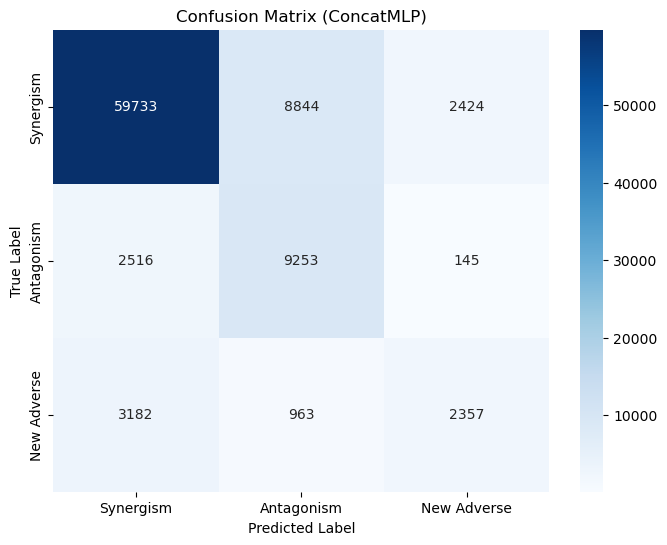

In [ ]:
cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Synergism', 'Antagonism', 'New Adverse'],
    yticklabels=['Synergism', 'Antagonism', 'New Adverse']
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

## Per-class classification report

This is especially important for imbalanced datasets, where overall accuracy can hide poor minority-class performance.

In [ ]:
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    target_names=['Synergism', 'Antagonism', 'New Adverse'],
    digits=4
))

              precision    recall  f1-score   support

   Synergism     0.9129    0.8413    0.8756     71001
  Antagonism     0.4855    0.7766    0.5975     11914
 New Adverse     0.4785    0.3625    0.4125      6502

    accuracy                         0.7979     89417
   macro avg     0.6256    0.6602    0.6285     89417
weighted avg     0.8244    0.7979    0.8049     89417



## ROC curves

This evaluates how well the model separates each class from the others across probability thresholds.

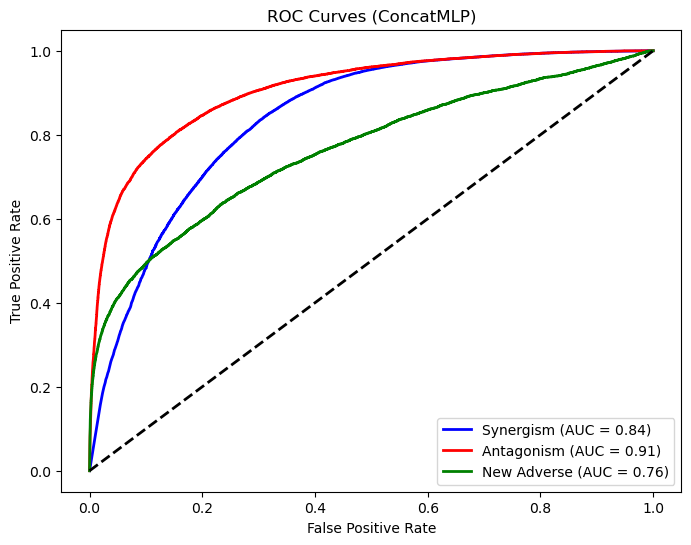

In [ ]:
n_classes = 3
y_test_bin = label_binarize(test_metrics["labels"], classes=[0, 1, 2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_metrics["probs"][:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
class_names = ['Synergism', 'Antagonism', 'New Adverse']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves ({best_model_name})")
plt.legend(loc="lower right")
plt.show()

## Plot learning curves

This helps compare training stability and overfitting behavior across candidate interaction models.

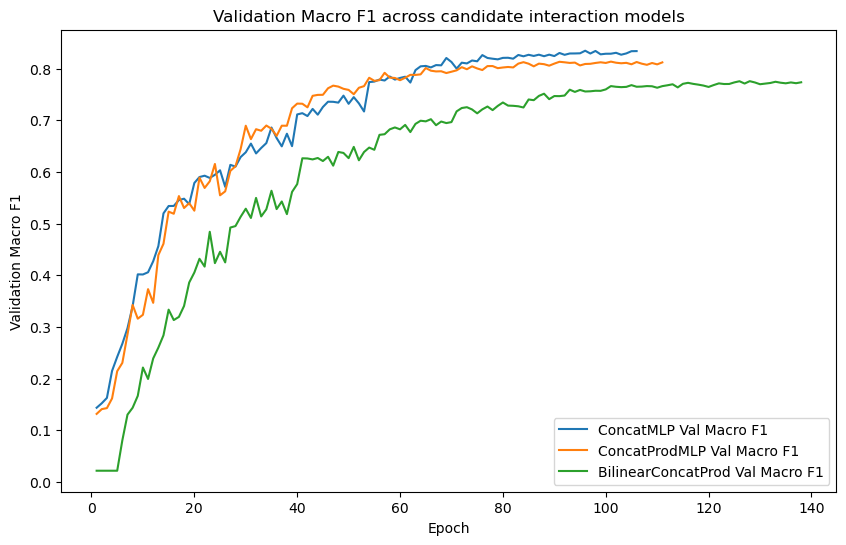

In [ ]:
plt.figure(figsize=(10, 6))

for model_name, hist_df in all_histories.items():
    plt.plot(hist_df["epoch"], hist_df["val_macro_f1"], label=f"{model_name} Val Macro F1")

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("Validation Macro F1 across candidate interaction models")
plt.legend()
plt.show()